# 7CS033 Workshop 6 Exercises

In [11]:
!pip install wordcloud

Complete all the exercises.

First, try to solve the questions independently, and then review the solutions. If you are struggling with a question, try using independant research to look for useful functions to help solve the problem. Ensure you understand the given solution to each problem before moving on to the next.

We are using the Reviews.csv data which can be found on Canvas.

## Importing necessary Libraries  

In [1]:
import pandas as pd
import numpy as np

##### Q1: Write code to import the Reviews.csv data. Investigate the dataset and extract a sample of ten thousand reviews.

In [3]:
#solution

df = pd.read_csv('Reviews.csv')
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [5]:
print(df.shape)
print(df.isna().sum())

(568454, 10)
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [7]:
# We can see that there are some missing values, given the size of our dataset we will drop those rows with missing values.

df.dropna(inplace = True)

#extract a sample
df = df.sample(n = 10000, random_state = 42)
df.reset_index(drop = True, inplace = True)
print(df.shape)
df.head()

(10000, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,450027,B000EF3E5O,AGOH8N902URMW,"Zeb ""zebra01""",7,8,5,1210550400,Very High quality Tuna,In the past this product was only sold through...
1,287936,B000Z8P34A,A1421EDED1JI4I,"H. Scott ""pop culture fan""",2,2,5,1255132800,Brilliant Product - LOVE this garlic spray,I found this spray in a gourmet food store and...
2,493300,B003TC7WN4,A3R7R8ARVN2P3D,A. Kehoe Jr.,1,1,4,1313020800,"Great, but not perfect",I roast my own Colombian beans at home so I ha...
3,203462,B000CQC04Q,A3MD537ZXBMFKR,Divegoddess,0,1,2,1321574400,Gross,"Tasted artificial, weird, unnatural. Could no..."
4,148753,B000H7F78Q,A1X0RLJE60LPHW,T. Taylor,2,2,3,1244246400,They melt in the heat!,I really like these cookies. They are a chocoh...


##### Q2: Write code to plot a histogram of the "Score" column. What do you notice?

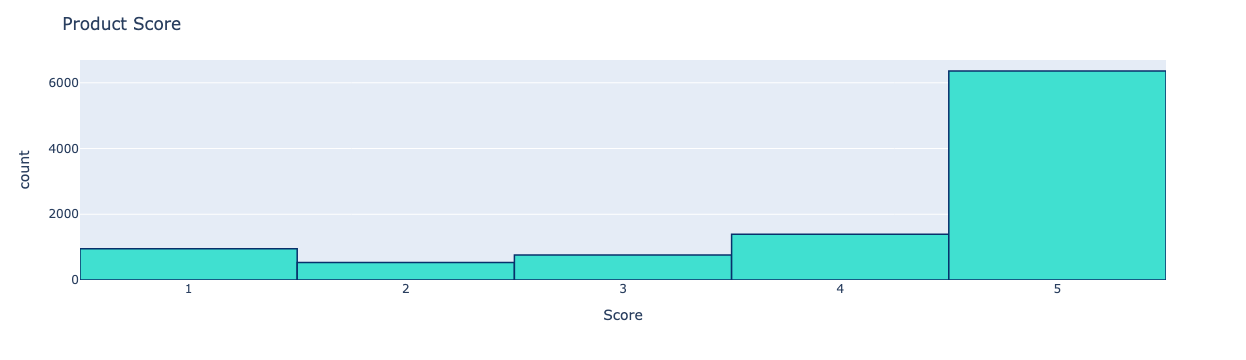

In [8]:
#Solution

#I thought it might be fun to look at how we can make interactive visuals using python. T
import matplotlib.pyplot as plt
import seaborn as sns

color = sns.color_palette()

import plotly.offline as py #plotly is an interactive plotting library
py.init_notebook_mode(connected=True) #this ensures plotly will work inside a jupyter notebook

#plotly.express contains functions useful for plotting

import plotly.express as px
%matplotlib inline
    
# Product Scores
fig = px.histogram(df, x="Score")
fig.update_traces(marker_color="turquoise",marker_line_color='rgb(8,48,107)', #update traces is for modifying aethetics, change these and see what happens
                  marker_line_width=1.5)
fig.update_layout(title_text='Product Score') #add a title
fig.show()

We can see that a review score of 5 is much more frequent in the dataset. This class imbalance can lead to any downpipe models learning to favour the overrepresented class during training. However, since we did not explore the distribution in the original dataset we cannt say with any certainty that this imbalance is not representative of the data. We could consider futher exploring the intial dataset to check this.

##### Q3: Write code to create a wordcloud of the 'text' feature. Remove stopwords prior to creating the wordcloud.

In [12]:
#solution

import nltk
from wordcloud import WordCloud
from wordcloud import STOPWORDS #in lecture we used the nltk stopwords list. The wordcloud library can also be used for this

# Create stopword list:
stopwords = set(STOPWORDS)
print(stopwords)

{'all', 'k', "wasn't", 'further', 'here', 'when', "he'd", 'while', 'can', 'you', 'would', 'by', 'there', 'because', 'very', 'him', 'during', 'such', 'otherwise', 'but', 'being', 'however', 'only', 'about', 'these', 'did', 'each', 'does', 'be', "shan't", 'yours', "couldn't", 'once', 'also', 'both', 'who', 'doing', "here's", "doesn't", 'whom', 'more', 'or', "isn't", "you'll", "they'd", 'was', 'com', "weren't", 'for', 'herself', 'myself', 'other', "haven't", 'the', 'those', 'therefore', "who's", "why's", "it's", 'yourselves', 'until', 'hence', 'our', "don't", 'which', 'no', 'were', 'any', 'get', 'own', 'after', 'so', "what's", 'i', "there's", 'are', 'at', 'why', 'what', 'nor', 'up', 'that', "didn't", "you'd", 'between', 'its', "we'd", 'this', 'above', "won't", 'under', 'into', 'himself', 'to', "i'm", 'should', "hadn't", 'as', 'few', 'them', "we're", 'been', 'http', "you've", "can't", 'same', 'they', 'having', 'your', 'yourself', 'ours', 'else', 'then', 'from', 'like', "mustn't", 'on', 'to

In [ ]:
#next we can remove the stopwords and generate a wordcloud

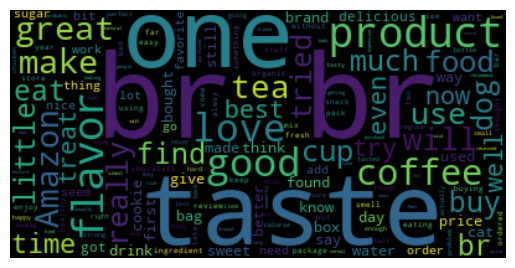

In [19]:
textt = " ".join(review for review in df.Text) #i create one large string of all the reviews combined

wordcloud = WordCloud(stopwords=stopwords).generate(textt) #then create the wordcloud excluding stopwords

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
#I notice that "br" seems to be frequent in the text. Lets remove that and generate a new word cloud

stopwords.update(["br"]) #this updates the stopwords list with our new stopword

textt = " ".join(review for review in df.Text) 
wordcloud = WordCloud(stopwords=stopwords).generate(textt)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

##### Q4: Write code to create sentiment labels for the review scores. All review scores greater than three should be considered positive and labelled with a '1'. All review scores equal to three should be considered neutral and removed. All review scores less than three should be considered negative and labelled with a '-1'.

In [21]:
#solution

df = df[df['Score'] != 3] #update the df removing any scores equal to 3

df['sentiment'] = df['Score'].apply(lambda rating: +1 if rating >3 else -1)
df.sample(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment
6845,546412,B00176G4A6,A3SC3T5GGVLRAS,Kat Freeman,1,1,1,1329091200,SKIMPY for the price charged!! Shocked!,Was shocked at the skinny size of this item!! ...,-1
1211,370648,B001GINOP8,A2URXWRESFFOLJ,"Freddie S. Kerr ""Suzy Q""",0,0,5,1246060800,Favorite Snack Of The Day,I would recommend anyone to try this especiall...,1
9734,327966,B000H7MHIO,A30VW5U99E33UP,All Natural M,0,0,5,1265500800,Heavenly Taste..,OMG<br />These cookies are perfection. They'r...,1
7572,167332,B007PE7ANY,A3EAP2VG0BVYWX,nekojita,1,2,4,1341360000,very nutty bars,These are very nutty bars with a nice dose of ...,1
6160,17650,B003QWN6B4,A2YO8731SKDKLL,Goofball,0,0,5,1337212800,"Better than a mounds bar, this was awesome","These are a great mini snack and treat, really...",1
3188,342915,B000EDG4K8,A3QDGKE0NAS0WO,sunclov,1,1,5,1334016000,The best!!,"This is the best and CHEAPEST, soy protein pow...",1
3646,281980,B002K8CUVC,A32OG5EVLN9EJ1,Ross Presser,1,12,2,1272672000,Don't. Just don't.,"I haven't tried this coffee, and I hope I neve...",-1
5867,365064,B001E95KUQ,A313H6238N589,"Jaewoo Kim ""OB-Wan""",22,23,5,1248652800,"Best instant coffee I have tasted, including t...",You will not disappointed with the quality of ...,1
665,485140,B0017WO2H2,A2WK4JKR8S9SFL,"Karleton Helfer ""Karleton Helfer""",0,0,5,1262044800,"TAZO Organic Apple Red is GREAT, buy some",The following recommendation is based on havin...,1
6378,423393,B005VOONGM,AT9U5ZE5OO84C,"M. Kooiman ""nerdette""",0,1,5,1333929600,Makes you want to sing!,This tastes like I remember coffee tasting and...,1


##### Q5: Write code to produce a wordcloud for the summaries of reviews with positive sentiment. Do the same for reviews with negative sentiment.

In [22]:
#Solution

#begin by splitting into positive and negative snetiments

positive = df[df['sentiment'] == 1]
negative = df[df['sentiment'] == -1]

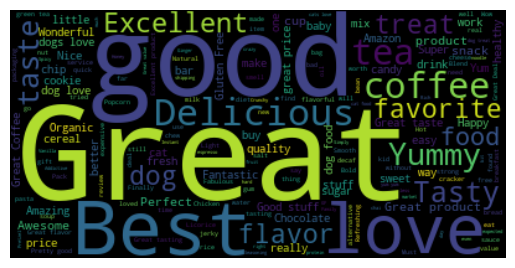

In [23]:
#create the positive sentiment wordcloud 

pos = " ".join(review for review in positive.Summary)
positive_word_cloud = WordCloud(stopwords = stopwords).generate(pos)
plt.imshow(positive_word_cloud, interpolation = 'bilinear')
plt.axis("off")
plt.show()

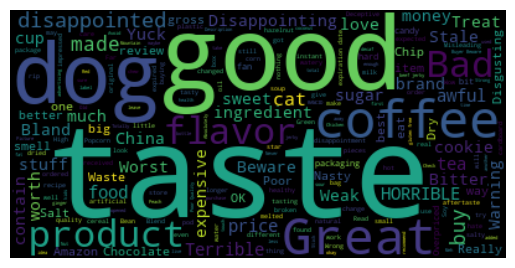

In [24]:
neg = " ".join(review for review in negative.Summary)
negative_word_cloud = WordCloud(stopwords = stopwords).generate(neg)
plt.imshow(negative_word_cloud, interpolation = 'bilinear')
plt.axis("off")
plt.show()

##### Q6: Write code to produce a histogram to investigate the distribution of the reviews.

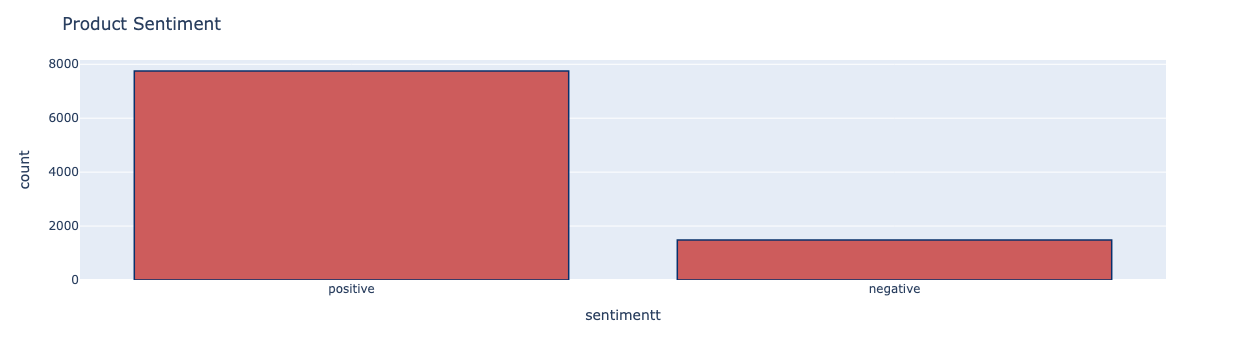

In [25]:
#Solution

#we could just use our labels of -1 and 1 but for visualisation purposes it can be useful to have the text label
df['sentimentt'] = df['sentiment'].replace({-1 : 'negative'})
df['sentimentt'] = df['sentimentt'].replace({1 : 'positive'})
#now we have a new column 'sentimentt' with the textual labels

fig = px.histogram(df, x="sentimentt")
fig.update_traces(marker_color="indianred",marker_line_color='rgb(8,48,107)',
                  marker_line_width=1.5)
fig.update_layout(title_text='Product Sentiment')
fig.show()

##### Q7: Write code to demonstrate two ways we could remove punctuation from the 'text' and 'summary' features.

In [26]:
#Method 1 
#Here I define a function and pick the specific punctuation I want removed myself

def remove_punctuation(text):
    final = "".join(u for u in text if u not in ("?", ".", ";", ":", "!",'"', ","))
    return final

df['Text'] = df['Text'].apply(remove_punctuation)
df['Summary'] = df['Summary'].apply(remove_punctuation)

df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment,sentimentt
0,450027,B000EF3E5O,AGOH8N902URMW,"Zeb ""zebra01""",7,8,5,1210550400,Very High quality Tuna,In the past this product was only sold through...,1,positive
1,287936,B000Z8P34A,A1421EDED1JI4I,"H. Scott ""pop culture fan""",2,2,5,1255132800,Brilliant Product - LOVE this garlic spray,I found this spray in a gourmet food store and...,1,positive
2,493300,B003TC7WN4,A3R7R8ARVN2P3D,A. Kehoe Jr.,1,1,4,1313020800,Great but not perfect,I roast my own Colombian beans at home so I ha...,1,positive
3,203462,B000CQC04Q,A3MD537ZXBMFKR,Divegoddess,0,1,2,1321574400,Gross,Tasted artificial weird unnatural Could not d...,-1,negative
5,277347,B000VK8AVK,A2OG042EUQ8XG5,Diane Haynes,0,0,5,1318377600,Wonderful ( I purchased them from Amazoncom) L...,These chips taste great You will not go wrong ...,1,positive
...,...,...,...,...,...,...,...,...,...,...,...,...
9994,129956,B001ET5Y4I,A1WL6D2PMATMT8,Jillian,2,2,5,1228003200,Delicious dried fruit,Juicy delicious dried cranberries I use them a...,1,positive
9995,416981,B004S036MM,A2XH4K3HJAE51N,Yehudit,0,0,5,1319068800,The real thing,This was so good I lived in Mexico for 20 yea...,1,positive
9996,363190,B000SATGHK,A3MQ68M8KRBUQH,Claudia,1,1,5,1340928000,Great for iced or hot tea,I like brewing loose tea and enjoy Davidson's ...,1,positive
9997,355878,B002QWP8H0,A233GJE85LAE9H,"LisaMVP ""LisaMVP""",0,0,5,1308009600,Freshens breath and my Yorkie loves 'em,When my Yorkie was about 10 1/2 years old her ...,1,positive


In [27]:
#method 2

import string

df['Text']=df['Text'].apply(lambda x:''.join(i for i in x if i not in string.punctuation))
df['Summary']=df['Summary'].apply(lambda x:''.join(i for i in x if i not in string.punctuation))

df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment,sentimentt
0,450027,B000EF3E5O,AGOH8N902URMW,"Zeb ""zebra01""",7,8,5,1210550400,Very High quality Tuna,In the past this product was only sold through...,1,positive
1,287936,B000Z8P34A,A1421EDED1JI4I,"H. Scott ""pop culture fan""",2,2,5,1255132800,Brilliant Product LOVE this garlic spray,I found this spray in a gourmet food store and...,1,positive
2,493300,B003TC7WN4,A3R7R8ARVN2P3D,A. Kehoe Jr.,1,1,4,1313020800,Great but not perfect,I roast my own Colombian beans at home so I ha...,1,positive
3,203462,B000CQC04Q,A3MD537ZXBMFKR,Divegoddess,0,1,2,1321574400,Gross,Tasted artificial weird unnatural Could not d...,-1,negative
5,277347,B000VK8AVK,A2OG042EUQ8XG5,Diane Haynes,0,0,5,1318377600,Wonderful I purchased them from Amazoncom Lov...,These chips taste great You will not go wrong ...,1,positive
...,...,...,...,...,...,...,...,...,...,...,...,...
9994,129956,B001ET5Y4I,A1WL6D2PMATMT8,Jillian,2,2,5,1228003200,Delicious dried fruit,Juicy delicious dried cranberries I use them a...,1,positive
9995,416981,B004S036MM,A2XH4K3HJAE51N,Yehudit,0,0,5,1319068800,The real thing,This was so good I lived in Mexico for 20 yea...,1,positive
9996,363190,B000SATGHK,A3MQ68M8KRBUQH,Claudia,1,1,5,1340928000,Great for iced or hot tea,I like brewing loose tea and enjoy Davidsons l...,1,positive
9997,355878,B002QWP8H0,A233GJE85LAE9H,"LisaMVP ""LisaMVP""",0,0,5,1308009600,Freshens breath and my Yorkie loves em,When my Yorkie was about 10 12 years old her b...,1,positive


The string.punctuation method is preferable here as it dealt with punctuation that we forgot in our own function.

##### Q8: Write code to remove stopwords from the 'Text' and 'Summary' features. Use the nltk stopwords list to do this.

In [28]:
#Solution

nltk.download('stopwords')
from nltk.corpus import stopwords
allstopwords = stopwords.words('english')
df['Text']=df.Text.apply(lambda x: " ".join(i for i in x.split() if i not in allstopwords))
df['Summary']=df.Summary.apply(lambda x: " ".join(i for i in x.split() if i not in allstopwords))

df

[nltk_data] Downloading package stopwords to /Users/oeze/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment,sentimentt
0,450027,B000EF3E5O,AGOH8N902URMW,"Zeb ""zebra01""",7,8,5,1210550400,Very High quality Tuna,In past product sold health food stores around...,1,positive
1,287936,B000Z8P34A,A1421EDED1JI4I,"H. Scott ""pop culture fan""",2,2,5,1255132800,Brilliant Product LOVE garlic spray,I found spray gourmet food store thought would...,1,positive
2,493300,B003TC7WN4,A3R7R8ARVN2P3D,A. Kehoe Jr.,1,1,4,1313020800,Great perfect,I roast Colombian beans home I perfect 10 refe...,1,positive
3,203462,B000CQC04Q,A3MD537ZXBMFKR,Divegoddess,0,1,2,1321574400,Gross,Tasted artificial weird unnatural Could detect...,-1,negative
5,277347,B000VK8AVK,A2OG042EUQ8XG5,Diane Haynes,0,0,5,1318377600,Wonderful I purchased Amazoncom Love Amazon,These chips taste great You go wrong low calor...,1,positive
...,...,...,...,...,...,...,...,...,...,...,...,...
9994,129956,B001ET5Y4I,A1WL6D2PMATMT8,Jillian,2,2,5,1228003200,Delicious dried fruit,Juicy delicious dried cranberries I use anywhe...,1,positive
9995,416981,B004S036MM,A2XH4K3HJAE51N,Yehudit,0,0,5,1319068800,The real thing,This good I lived Mexico 20 years mole I ate I...,1,positive
9996,363190,B000SATGHK,A3MQ68M8KRBUQH,Claudia,1,1,5,1340928000,Great iced hot tea,I like brewing loose tea enjoy Davidsons loose...,1,positive
9997,355878,B002QWP8H0,A233GJE85LAE9H,"LisaMVP ""LisaMVP""",0,0,5,1308009600,Freshens breath Yorkie loves em,When Yorkie 10 12 years old breath suddenly be...,1,positive


##### Q9: Write code to create a input variable 'X' of the 'Summary' feature and target variable 'y' of the 'sentiment' feature. Use the sklearn CountVectorizer() method to convert text data in X into numeric form.

In [29]:
#Solution

from sklearn.feature_extraction.text import CountVectorizer

X = df['Summary']
y = df['sentiment']

#we use countvectorizer to convert the text into a sparse matrix of counts. This will enable us to train ML models on our text data as it will 
#be represented numerically

vectorizer = CountVectorizer(token_pattern = r'\b\w+\b') 
#the token pattern tells wordvectorizer how the text should be tokenized. 
#here we specified the tokens will start at a word boundry '\b' then must contain at least 2 characters 'w+' and then ends at a word boundry '\b'
#note that set up this way words of length 1 will be ignored

X = vectorizer.fit_transform(X)

#below I convert this into a dataframe just so we can see what the count vectorizer has done
vectorized_df = pd.DataFrame(X.toarray(), columns = vectorizer.get_feature_names_out())
print(vectorized_df.columns)
vectorized_df

#This is similar to one hot encoding, however one hot encoding is for categorical data wheras count vectorizer is for text data.

Index(['0', '075', '1', '10', '100', '1000', '102011', '1073', '108',
       '10count',
       ...
       'zip', 'ziyad', 'zoe', 'zoes', 'zots', 'zotz', 'zuke', 'zukes',
       'zylitol', 'zz'],
      dtype='str', length=5019)


,0,075,1,10,100,1000,102011,1073,108,10count,...,zip,ziyad,zoe,zoes,zots,zotz,zuke,zukes,zylitol,zz
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9231,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9232,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9233,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9234,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


##### Q10: Write code to train six classifiers to predict the sentiment of a review summary.

In [30]:
#split the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

#define our classification models
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
SVM = svm.SVC()
RF = RandomForestClassifier()
KNN = KNeighborsClassifier()
DT = DecisionTreeClassifier()
NB = GaussianNB()
LR = LogisticRegression()

#train the models
SVM.fit(X_train, y_train)
RF.fit(X_train, y_train)
KNN.fit(X_train, y_train)
DT.fit(X_train, y_train)
LR.fit(X_train,y_train)
NB.fit(X_train.toarray(),y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


##### Q11: Write code to create confusion  matrices for each of your models. Print evaluation metrics for each model.

In [31]:
#make predictions on the test set
SVM_pred = SVM.predict(X_test)
RF_pred = RF.predict(X_test)
KNN_pred = KNN.predict(X_test)
DT_pred = DT.predict(X_test)
LR_pred = LR.predict(X_test)
NB_pred = NB.predict(X_test.toarray())

#Make confusion matrices for the above
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SVM_cm = confusion_matrix(y_test, SVM_pred, labels = SVM.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = SVM_cm, display_labels = SVM.classes_)
disp.plot()
plt.title("SVM")

RF_cm = confusion_matrix(y_test, RF_pred, labels = RF.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = RF_cm,display_labels = RF.classes_)
disp.plot()
plt.title("RF")


KNN_cm = confusion_matrix(y_test, KNN_pred, labels = KNN.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = KNN_cm, display_labels = KNN.classes_)
disp.plot()
plt.title("KNN")

DT_cm = confusion_matrix(y_test, DT_pred, labels = DT.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = DT_cm, display_labels = DT.classes_)
disp.plot()
plt.title("DT")

LR_cm = confusion_matrix(y_test, LR_pred, labels = LR.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = LR_cm, display_labels = LR.classes_)
disp.plot()
plt.title("LR")

NB_cm = confusion_matrix(y_test, NB_pred, labels = NB.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = NB_cm, display_labels = NB.classes_)
disp.plot()
plt.title("NB")

Text(0.5, 1.0, 'NB')

In [32]:
#Next we will write a function that takes in the confusion matrices we generated previously and produces evaluation metrics 

def confusion_metrics (conf_matrix):

    TP = conf_matrix[1][1]
    TN = conf_matrix[0][0]
    FP = conf_matrix[0][1]
    FN = conf_matrix[1][0]
    print('True Positives:', TP)
    print('True Negatives:', TN)
    print('False Positives:', FP)
    print('False Negatives:', FN)

    # calculate accuracy
    conf_accuracy = (float (TP+TN) / float(TP + TN + FP + FN))

    # calculate mis-classification
    conf_misclassification = 1- conf_accuracy

    # calculate the recall
    conf_recall = (TP / float(TP + FN))
    # calculate the specificity
    conf_specificity = (TN / float(TN + FP))

    # calculate precision
    conf_precision = (TN / float(TN + FP))
    # calculate f_1 score
    conf_f1 = 2 * ((conf_precision * conf_recall) / (conf_precision + conf_recall))
    print('-'*50)
    print(f'Accuracy: {round(conf_accuracy,2)}')
    print(f'Mis-Classification: {round(conf_misclassification,2)}')
    print(f'Recall: {round(conf_recall,2)}')
    print(f'Specificity: {round(conf_specificity,2)}')
    print(f'Precision: {round(conf_precision,2)}')
    print(f'f_1 Score: {round(conf_f1,2)}')

#Finally use the function to output the evaluation metrics for all classifiers
print('SVM metrics\n')
confusion_metrics(SVM_cm)
print('\n\n')
print('RF metrics\n')
confusion_metrics(RF_cm)
print('\n\n')
print('KNN metrics\n')
confusion_metrics(KNN_cm)
print('\n\n')
print('DT metrics\n')
confusion_metrics(DT_cm)
print('\n\n')
print('LR metrics\n')
confusion_metrics(LR_cm)
print('\n\n')
print('NB metrics\n')
confusion_metrics(NB_cm)
print('\n\n')

SVM metrics

True Positives: 2291
True Negatives: 155
False Positives: 298
False Negatives: 27
--------------------------------------------------
Accuracy: 0.88
Mis-Classification: 0.12
Recall: 0.99
Specificity: 0.34
Precision: 0.34
f_1 Score: 0.51



RF metrics

True Positives: 2190
True Negatives: 251
False Positives: 202
False Negatives: 128
--------------------------------------------------
Accuracy: 0.88
Mis-Classification: 0.12
Recall: 0.94
Specificity: 0.55
Precision: 0.55
f_1 Score: 0.7



KNN metrics

True Positives: 2263
True Negatives: 154
False Positives: 299
False Negatives: 55
--------------------------------------------------
Accuracy: 0.87
Mis-Classification: 0.13
Recall: 0.98
Specificity: 0.34
Precision: 0.34
f_1 Score: 0.5



DT metrics

True Positives: 2131
True Negatives: 259
False Positives: 194
False Negatives: 187
--------------------------------------------------
Accuracy: 0.86
Mis-Classification: 0.14
Recall: 0.92
Specificity: 0.57
Precision: 0.57
f_1 Score: 0.